In [49]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (20, 10)

In [50]:
ps = ['omni_min_def_IMF_Bz_AE_AL_AU_20050225T000000_20050225T235959.txt','omni_min_def_IMF_Bz_AE_AL_AU_20090408T000000_20090408T235959.txt','omni_min_def_IMF_Bz_AE_AL_AU_20091019T000000_20091019T235959.txt']  # all data download from OMNIWeb

In [51]:
# 定义列名
columns = ['Year', 'DoY', 'Hour','Minute', 'IMF_Bz','AE','AL','AU']
def get_IMF_Bz_AE_AL_AU(path):
    # 创建空的列表，用于存储数据
    data = []
    # 读取文件，过滤掉表头和注释行
    with open(path, 'r') as file:
        for line in file:
            # 按空格分隔字段并移除多余的空格
            fields = line.strip().split()
            data.append(fields)
    # 将数据转换为 Pandas DataFrame
    df = pd.DataFrame(data, columns=columns)
    # 定义一个新的列，将 Year、DOY、Hour、Minute 组合成一个字符串格式
    df['Datetime'] = pd.to_datetime(df['Year'].astype(str) + df['DoY'].astype(str).str.zfill(3) + df['Hour'].astype(str).str.zfill(2) + df['Minute'].astype(str).str.zfill(2),
                                    format='%Y%j%H%M')
    df[['IMF_Bz','AE','AL','AU']] = df[['IMF_Bz','AE','AL','AU']].apply(pd.to_numeric)
    # set index to datatime
    df = df.set_index(df['Datetime'])
    # 删除 Year, DoY, Hour, Minute 列
    df = df.drop(columns=['Year', 'DoY', 'Hour', 'Minute','Datetime'])
    return df

data = get_IMF_Bz_AE_AL_AU(ps[0])

In [52]:
IMF_Bz = data['IMF_Bz']
AE = data['AE']
AL = data['AL']
AU = data['AU']

In [53]:
IMF_Bz.replace(9999.99,np.nan,inplace=True)  # refer to corresponding file doc
# do not use pd.NA, it will result in object column, i.e. different type elements in one column.
IMF_Bz.interpolate(inplace=True)

# 3 phases

## funcs

In [54]:
def get_intervals(data,condition):
    filtered_dates = data[condition]
    gaps = (filtered_dates.index.to_series().diff() > pd.Timedelta(minutes=1)).cumsum()  # default time_resolution is 1 min.
    # 将这些时间点分组成不同的区间
    intervals = filtered_dates.groupby(gaps).apply(lambda x: (x.index[0], x.index[-1]))  # todo: apply?
    return intervals

In [55]:
def merge_intervals(intervals):
    # 初始化合并后的 intervals 列表
    merged_intervals = []
    # 从第一个 interval 开始
    current_start, current_end = intervals.iloc[0][0], intervals.iloc[0][1]
    for i in range(1, len(intervals)):
        next_start, next_end = intervals.iloc[i][0], intervals.iloc[i][1]
        # 检查相邻 interval 的时间间隔是否小于 12.5 分钟
        if (next_start - current_end) <= pd.Timedelta(minutes=12.5):
            # 如果时间间隔小于 12.5 分钟，合并 interval
            current_end = next_end
        else:
            # 如果不满足合并条件，将当前的 interval 添加到结果中
            merged_intervals.append((current_start, current_end))
            # 更新当前 interval 为下一个 interval
            current_start, current_end = next_start, next_end
    # 添加最后一个 interval
    merged_intervals.append((current_start, current_end))
    # 将结果转换为 DataFrame 方便查看
    merged_intervals_df = pd.DataFrame(merged_intervals, columns=['start', 'end'])
    return merged_intervals_df

## expansion

### condition1

In [56]:
AL_diff = AL.diff()
intervals_expansion1 = get_intervals(AL_diff, AL_diff < -4)

### condition2

In [57]:
# 对每个interval在原series中进行切片并获取最小值
min_values = intervals_expansion1.apply(lambda x: AL[x[0]:x[1]].min())
# 保留最小值小于 -50 的区间
intervals_expansion12 = intervals_expansion1[min_values < -50]

### merge

In [58]:
merged_intervals_expansion = merge_intervals(intervals_expansion12)
merged_intervals_expansion

,start,end
0,2005-02-25 00:01:00,2005-02-25 00:03:00
1,2005-02-25 00:16:00,2005-02-25 00:30:00
2,2005-02-25 06:42:00,2005-02-25 06:54:00
3,2005-02-25 07:58:00,2005-02-25 11:10:00
4,2005-02-25 11:30:00,2005-02-25 12:03:00
5,2005-02-25 12:16:00,2005-02-25 12:19:00
6,2005-02-25 13:01:00,2005-02-25 13:15:00
7,2005-02-25 13:28:00,2005-02-25 13:28:00
8,2005-02-25 13:54:00,2005-02-25 13:54:00
9,2005-02-25 14:11:00,2005-02-25 14:12:00


## recovery

### condition

In [59]:
intervals_recovery = get_intervals(AL, AL < -50)

### merge

In [60]:
merged_intervals_recovery = merge_intervals(intervals_recovery)

## growth

In [61]:
intervals_growth = get_intervals(IMF_Bz, IMF_Bz < 0)

In [62]:
# pd.DataFrame(list(intervals_growth),columns=['start','end'])

In [63]:
merged_intervals_growth = merge_intervals(intervals_growth)

# trim expansion

In [64]:
# # for looking the data clip
# AL[merged_intervals_expansion['start'][2]:merged_intervals_expansion['end'][2]]

In [65]:
# 初始化修剪后的 intervals 列表
trimmed_intervals_expansion = []

# 遍历每个 interval
for i in range(len(merged_intervals_expansion)):
    start = merged_intervals_expansion.iloc[i]['start']
    end = merged_intervals_expansion.iloc[i]['end']
    
    # 对 AL 进行切片
    sliced_AL = AL[start:end]
    
    # 找到最小值和最大值及其对应的时间点
    start_time = sliced_AL.idxmax()  # 最大值对应的时间点
    end_time = sliced_AL.idxmin()  # 最小值对应的时间点
    
    if start_time > end_time:
        continue
    
    # 修剪后的 interval 以最大值开始，最小值结束
    trimmed_intervals_expansion.append((start_time, end_time))

# 将结果转换为 DataFrame 方便查看
trimmed_intervals_expansion_df = pd.DataFrame(trimmed_intervals_expansion, columns=['start', 'end'])

# 打印修剪后的 intervals
print(trimmed_intervals_expansion_df)


                 start                 end
0  2005-02-25 00:01:00 2005-02-25 00:03:00
1  2005-02-25 06:42:00 2005-02-25 06:50:00
2  2005-02-25 08:23:00 2005-02-25 09:41:00
3  2005-02-25 12:18:00 2005-02-25 12:19:00
4  2005-02-25 13:01:00 2005-02-25 13:15:00
5  2005-02-25 13:28:00 2005-02-25 13:28:00
6  2005-02-25 13:54:00 2005-02-25 13:54:00
7  2005-02-25 14:11:00 2005-02-25 14:12:00
8  2005-02-25 14:32:00 2005-02-25 14:46:00
9  2005-02-25 15:03:00 2005-02-25 15:31:00
10 2005-02-25 15:44:00 2005-02-25 15:44:00
11 2005-02-25 15:57:00 2005-02-25 16:40:00
12 2005-02-25 16:57:00 2005-02-25 18:11:00
13 2005-02-25 19:26:00 2005-02-25 19:29:00
14 2005-02-25 20:07:00 2005-02-25 20:17:00
15 2005-02-25 20:45:00 2005-02-25 21:12:00
16 2005-02-25 21:29:00 2005-02-25 21:36:00
17 2005-02-25 21:59:00 2005-02-25 21:59:00
18 2005-02-25 22:35:00 2005-02-25 22:56:00
19 2005-02-25 23:33:00 2005-02-25 23:49:00


# remove interval that only last 1 minute

In [66]:
def remove_1m_interval(intervals):
    """
    
    @param intervals: DataFrame with 2 columns: ['start', 'end']
    @return: the same type as intervals
    """
    # 删除长度为 1 分钟的 interval（即 start 和 end 时间相同）
    return intervals[intervals['start'] != intervals['end']]

In [67]:
remove_1m_intervals_expansion = remove_1m_interval(trimmed_intervals_expansion_df)
remove_1m_intervals_recovery = remove_1m_interval(merged_intervals_recovery)
remove_1m_intervals_growth = remove_1m_interval(merged_intervals_growth)

# using priority to deal with overlapping

In [68]:
def apply_priority_to_phases_intervals(high_priority_intervals, low_priority_intervals):
    # 初始化一个新的 DataFrame 来存储修剪后的 recovery_intervals
    adjusted_low_priority_intervals = []
    
    # 遍历 recovery_intervals 的每个 interval
    for i, recovery in low_priority_intervals.iterrows():
        recovery_start = recovery['start']
        recovery_end = recovery['end']
        
        for _, expansion in high_priority_intervals.iterrows():
            expansion_start = expansion['start']
            expansion_end = expansion['end']
            
            # 检查是否有重叠
            if recovery_start < expansion_end and recovery_end > expansion_start:
                # 重叠部分：调整 recovery_intervals，使其不重叠
                if recovery_start >= expansion_start and recovery_end <= expansion_end:
                    # 如果 recovery 的整个区间都被 expansion 覆盖，则跳过
                    recovery_start = recovery_end = None  # 该区间会被跳过
                    break
                elif recovery_start < expansion_start and recovery_end > expansion_end:
                    # 如果 recovery 包含 expansion 区间，切成两段
                    adjusted_low_priority_intervals.append({'start': recovery_start, 'end': expansion_start})
                    recovery_start = expansion_end
                elif recovery_start < expansion_start:
                    # 如果 recovery 的前半段不重叠，保留前半段
                    adjusted_low_priority_intervals.append({'start': recovery_start, 'end': expansion_start})
                    recovery_start = expansion_end
                elif recovery_end > expansion_end:
                    # 如果 recovery 的后半段不重叠，保留后半段
                    recovery_start = expansion_end
    
        # 如果重叠的调整后依旧有剩余部分
        if recovery_start is not None and recovery_end is not None and recovery_start < recovery_end:
            adjusted_low_priority_intervals.append({'start': recovery_start, 'end': recovery_end})
    
    # 将结果转换为 DataFrame
    adjusted_low_priority_intervals_df = pd.DataFrame(adjusted_low_priority_intervals)
    return adjusted_low_priority_intervals_df


In [69]:
adjusted_recovery_intervals = apply_priority_to_phases_intervals(remove_1m_intervals_expansion,remove_1m_intervals_recovery)
# 1. 筛选 recovery_intervals：recovery 的 start 必须是 expansion 的 end
follow_recovery_intervals = adjusted_recovery_intervals[adjusted_recovery_intervals['start'].isin(remove_1m_intervals_expansion['end'])]
adjusted_growth_intervals1 = apply_priority_to_phases_intervals(remove_1m_intervals_expansion,remove_1m_intervals_growth)
# adjusted_growth_intervals2 = apply_priority_to_phases_intervals(adjusted_recovery_intervals,adjusted_growth_intervals1)
adjusted_growth_intervals2 = apply_priority_to_phases_intervals(follow_recovery_intervals,adjusted_growth_intervals1)

# precede and follow

In [70]:
adjusted_growth_intervals2['end'].isin(remove_1m_intervals_expansion['start'])

0    False
1    False
2    False
3     True
4     True
5     True
Name: end, dtype: bool

In [71]:
# # 1. 筛选 recovery_intervals：recovery 的 start 必须是 expansion 的 end
# follow_recovery_intervals = adjusted_recovery_intervals[adjusted_recovery_intervals['start'].isin(remove_1m_intervals_expansion['end'])]

# 2. 筛选 growth_intervals：growth 的 end 必须是 expansion 的 start
precede_growth_intervals = adjusted_growth_intervals2[adjusted_growth_intervals2['end'].isin(remove_1m_intervals_expansion['start'])]

# 打印筛选后的结果
print("Filtered Recovery Intervals:")
print(follow_recovery_intervals)

print("\nFiltered Growth Intervals:")
print(precede_growth_intervals)


Filtered Recovery Intervals:
                 start                 end
1  2005-02-25 00:03:00 2005-02-25 00:43:00
2  2005-02-25 06:50:00 2005-02-25 06:58:00
4  2005-02-25 09:41:00 2005-02-25 12:18:00
5  2005-02-25 12:19:00 2005-02-25 12:22:00
7  2005-02-25 13:15:00 2005-02-25 13:58:00
8  2005-02-25 14:12:00 2005-02-25 14:32:00
9  2005-02-25 14:46:00 2005-02-25 15:03:00
10 2005-02-25 15:31:00 2005-02-25 15:57:00
11 2005-02-25 16:40:00 2005-02-25 16:57:00
12 2005-02-25 18:11:00 2005-02-25 19:26:00
13 2005-02-25 19:29:00 2005-02-25 20:07:00
14 2005-02-25 20:17:00 2005-02-25 20:25:00
16 2005-02-25 21:12:00 2005-02-25 21:29:00
17 2005-02-25 21:36:00 2005-02-25 22:10:00
19 2005-02-25 22:56:00 2005-02-25 23:33:00
20 2005-02-25 23:49:00 2005-02-25 23:59:00

Filtered Growth Intervals:
                start                 end
3 2005-02-25 07:59:00 2005-02-25 08:23:00
4 2005-02-25 12:39:00 2005-02-25 13:01:00
5 2005-02-25 20:37:00 2005-02-25 20:45:00


In [90]:
for _, exp_row in remove_1m_intervals_expansion.iterrows():
    print(exp_row)
    condition = (follow_recovery_intervals['start'] == exp_row['end'])
    if not condition.any():
        print('expansion without recovery')
        print("next match \n\n")
        continue
    recovery_match = follow_recovery_intervals[condition]
    # if not recovery_match:
    print(recovery_match.iloc[0,0], recovery_match.iloc[0,1])
    print("next match \n\n")

start   2005-02-25 00:01:00
end     2005-02-25 00:03:00
Name: 0, dtype: datetime64[ns]
2005-02-25 00:03:00 2005-02-25 00:43:00
next match 


start   2005-02-25 06:42:00
end     2005-02-25 06:50:00
Name: 1, dtype: datetime64[ns]
2005-02-25 06:50:00 2005-02-25 06:58:00
next match 


start   2005-02-25 08:23:00
end     2005-02-25 09:41:00
Name: 2, dtype: datetime64[ns]
2005-02-25 09:41:00 2005-02-25 12:18:00
next match 


start   2005-02-25 12:18:00
end     2005-02-25 12:19:00
Name: 3, dtype: datetime64[ns]
2005-02-25 12:19:00 2005-02-25 12:22:00
next match 


start   2005-02-25 13:01:00
end     2005-02-25 13:15:00
Name: 4, dtype: datetime64[ns]
2005-02-25 13:15:00 2005-02-25 13:58:00
next match 


start   2005-02-25 14:11:00
end     2005-02-25 14:12:00
Name: 7, dtype: datetime64[ns]
2005-02-25 14:12:00 2005-02-25 14:32:00
next match 


start   2005-02-25 14:32:00
end     2005-02-25 14:46:00
Name: 8, dtype: datetime64[ns]
2005-02-25 14:46:00 2005-02-25 15:03:00
next match 


start   2005-

In [92]:
pd.NaT

NaT

In [77]:
pd.to_datetime(precede_growth_intervals['start'])

3   2005-02-25 07:59:00
4   2005-02-25 12:39:00
5   2005-02-25 20:37:00
Name: start, dtype: datetime64[ns]

# plot

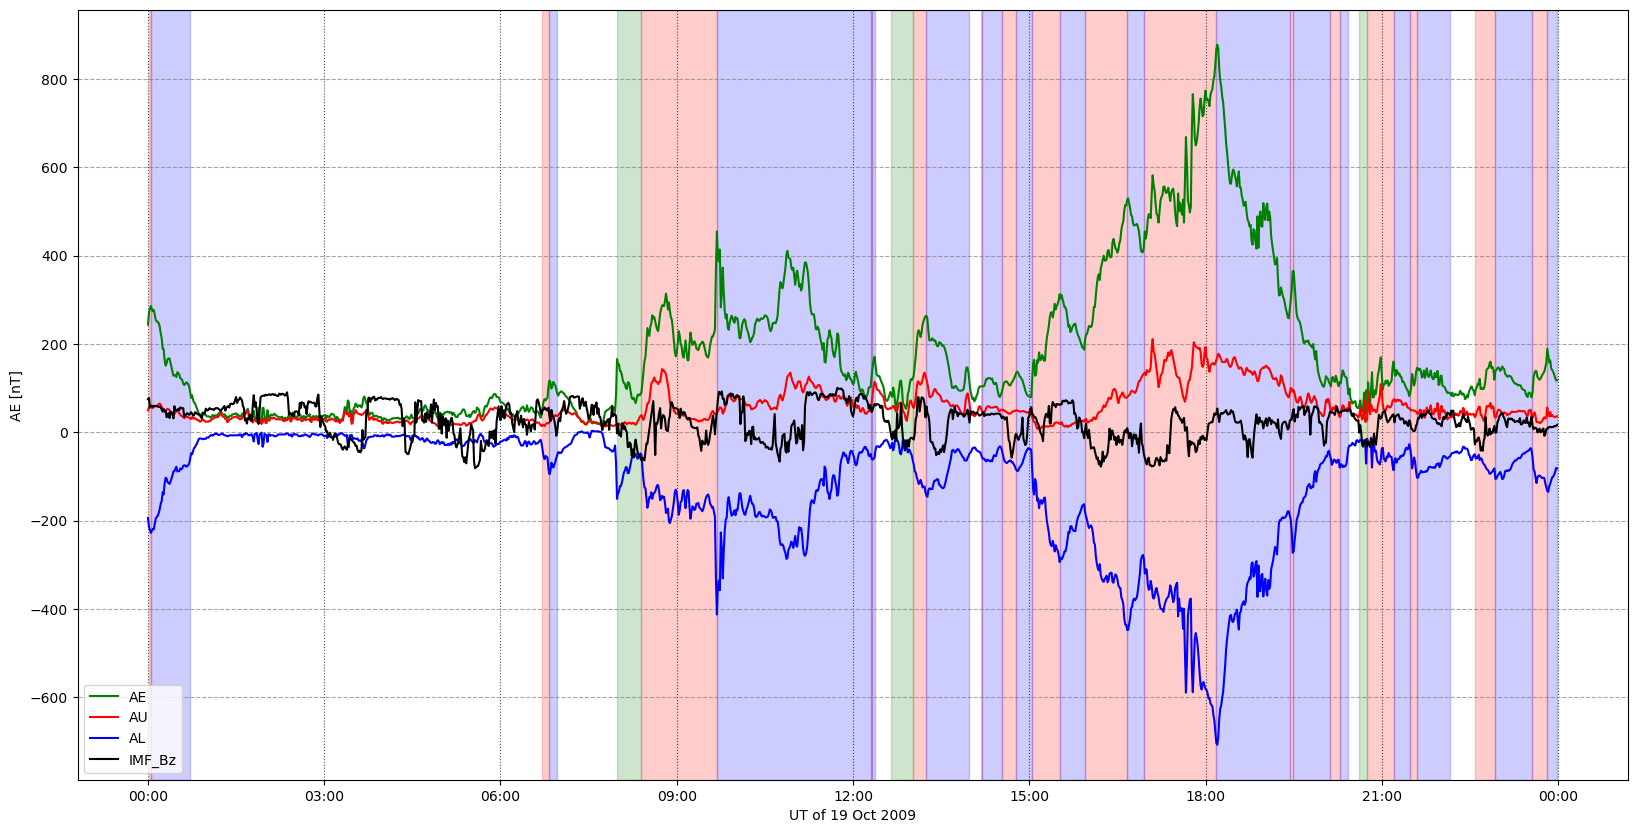

In [72]:
time = AL.index

plt.figure()
plt.plot(time,AE,label='AE', color='green')
plt.plot(time,AU,label='AU', color='red')
plt.plot(time,AL,label='AL', color='blue')
plt.plot(time,10*IMF_Bz,label='IMF_Bz', color='black')
# 
for _, row in remove_1m_intervals_expansion.iterrows():
# for _, row in merged_intervals_expansion.iterrows():
    plt.axvspan(row['start'], row['end'], color='red', alpha=0.2)
for _, row in follow_recovery_intervals.iterrows():
    plt.axvspan(row['start'], row['end'], color='blue', alpha=0.2)
for _, row in precede_growth_intervals.iterrows():
# for _, row in adjusted_growth_intervals2.iterrows():
    plt.axvspan(row['start'], row['end'], color='green', alpha=0.2)
# xticks_ = ['2009-10-19 00:00:00','2009-10-19 06:00:00','2009-10-19 12:00:00','2009-10-19 18:00:00','2009-10-20 00:00:00']
# plt.xticks(xticks_)  # 只显示“年月日”
# 自定义 x 轴刻度格式
ax = plt.gca()  # 获取当前的轴
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # 自动刻度定位器
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # 自定义时间显示格式
# 添加图例、标签等
plt.xlabel('UT of 19 Oct 2009')
plt.ylabel('AE [nT]')
# plt.title('AE, AL, AU indices over time')
plt.legend(loc='lower left')
# 显示垂直网格线
ax.grid(True, which='major', axis='x', linestyle=':', color='black', alpha=0.7)  # 设置 x 轴网格线
ax.grid(True, which='major', axis='y', linestyle='--', color='gray', alpha=0.7)  # 设置 y 轴网格线

# 显示图形
plt.show()

now, my reproduction is 99% in line with the original article. Only one expansion phase local AL maximum in 'UT of 08 APr 2009', my reproduction is in 12:00, the article seem to before 12:00 according to the corresponding figure.